In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional settings
pd.set_option('display.max_columns', None)

# Load datasets
events = pd.read_csv('RetailRocket/events.csv')
category_tree = pd.read_csv('RetailRocket/category_tree.csv')
item_props = pd.read_csv('RetailRocket/item_properties_part2.csv')
item_props2 = pd.read_csv('RetailRocket/item_properties_part1.csv')

# Quick look
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [3]:
#basic exploration
#how many users
#how many items
#what types of events exist
#how big is dataset
print("Events shape:", events.shape)
print(events.info())

events.describe(include='all')

Events shape: (2756101, 5)
<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          str    
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), str(1)
memory usage: 105.1 MB
None


,timestamp,visitorid,event,itemid,transactionid
count,2.756101e+06,2.756101e+06,2756101,2.756101e+06,22457.000000
unique,NaN,NaN,3,NaN,NaN
top,NaN,NaN,view,NaN,NaN
freq,NaN,NaN,2664312,NaN,NaN
mean,1.436424e+12,7.019229e+05,NaN,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,NaN,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,NaN,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,NaN,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,NaN,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,NaN,3.507150e+05,13224.000000


In [4]:
#event type dist.

events['event'].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

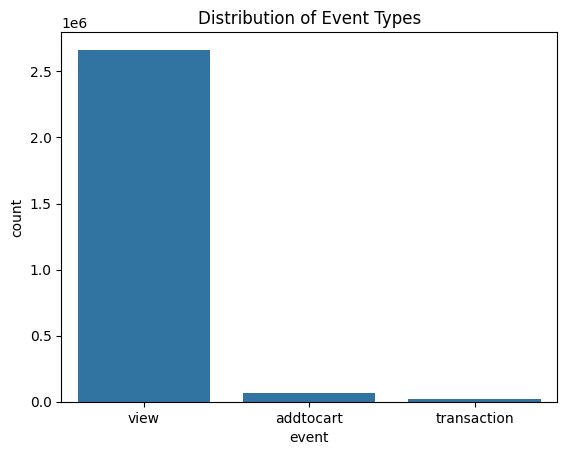

In [5]:
sns.countplot(data=events, x='event')
plt.title("Distribution of Event Types")
plt.show()

In [6]:
#unique counts

print("Unique users:", events['visitorid'].nunique())
print("Unique items:", events['itemid'].nunique())


Unique users: 1407580
Unique items: 235061


In [7]:
#interactions per user
user_counts = events['visitorid'].value_counts()

user_counts.describe()

count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
Name: count, dtype: float64

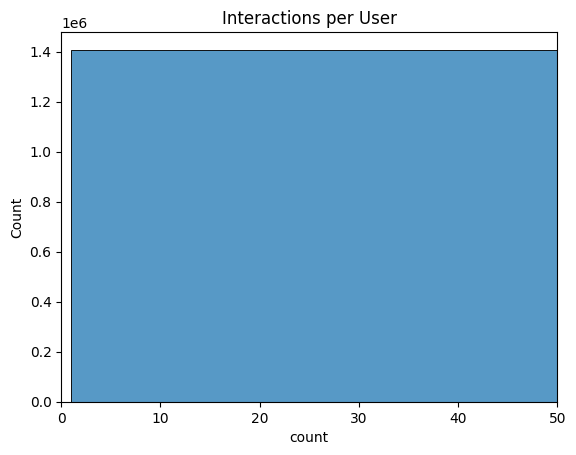

In [8]:
sns.histplot(user_counts, bins=50)
plt.title("Interactions per User")
plt.xlim(0, 50)
plt.show()

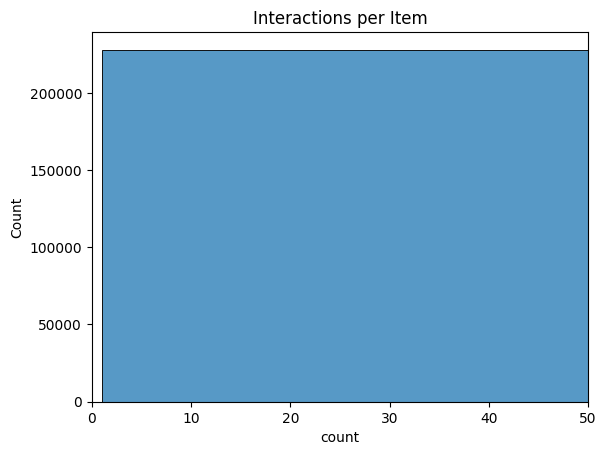

In [9]:
#interactions per item

item_counts = events['itemid'].value_counts()

sns.histplot(item_counts, bins=50)
plt.title("Interactions per Item")
plt.xlim(0, 50)
plt.show()

In [10]:
#convert timestamp

events['datetime'] = pd.to_datetime(events['timestamp'], unit='ms')

events['datetime'].head()

0   2015-06-02 05:02:12.117
1   2015-06-02 05:50:14.164
2   2015-06-02 05:13:19.827
3   2015-06-02 05:12:35.914
4   2015-06-02 05:02:17.106
Name: datetime, dtype: datetime64[ms]

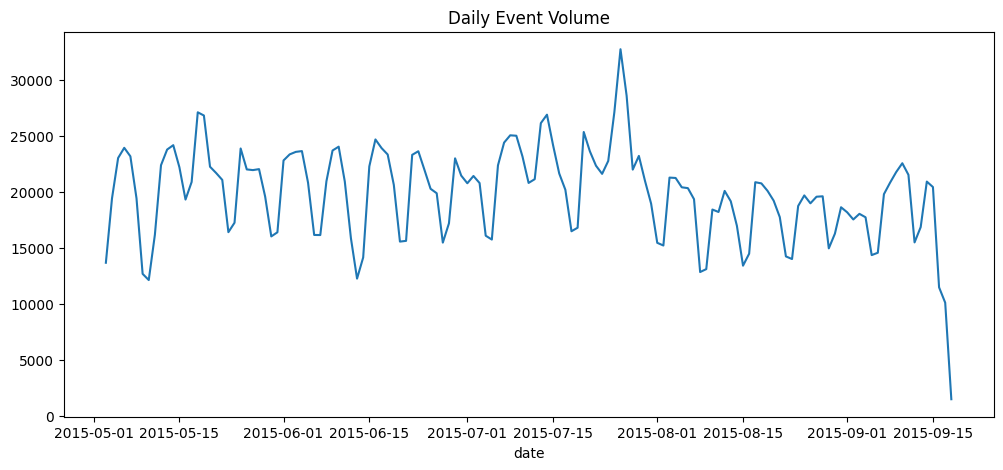

In [11]:
#time-based patterns

events['date'] = events['datetime'].dt.date

daily_events = events.groupby('date').size()

daily_events.plot(figsize=(12,5))
plt.title("Daily Event Volume")
plt.show()

In [12]:
#filter data

# Keep users with at least 5 interactions
user_counts = events['visitorid'].value_counts()
active_users = user_counts[user_counts >= 5].index

events_filtered = events[events['visitorid'].isin(active_users)]

# Keep items with at least 5 interactions
item_counts = events_filtered['itemid'].value_counts()
popular_items = item_counts[item_counts >= 5].index

events_filtered = events_filtered[events_filtered['itemid'].isin(popular_items)]

print(events_filtered.shape)

(833463, 7)


In [16]:
interaction_df = events_filtered.groupby(['visitorid', 'itemid']).size().reset_index(name='interaction_count')

interaction_df.head()

,visitorid,itemid,interaction_count
0,2,216305,2
1,2,259884,1
2,2,325215,3
3,2,342816,2
4,6,65273,1


In [17]:
interaction_df.to_csv('RetailRocket/interaction_df.csv', index=False)

In [19]:
events_filtered.to_csv('RetailRocket/events_filtered.csv', index = False)